# Model Interpretation & Explainability
In this notebook, we load previously saved models and perform interpretability analysis using SHAP.

## 1. Load Data & Models

In [25]:
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

print("Loading dataset...")
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

# Clean Sleep Disorder (to match preprocessing)
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "none": "None",
    "NONE": "None",
    "": "None"
})

drop_cols = ["Person ID", "Blood Pressure"]
target_col = "Quality of Sleep"
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]

X = df[feature_cols]
y = df[target_col]

print("Loading trained best model...")
best_model = joblib.load("saved_models/gradient_boosting.joblib")
best_model


Loading dataset...
Loading trained best model...


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Sleep Duration',
                                                   'Physical Activity Level',
                                                   'Stress Level', 'Heart Rate',
                                                   'Daily Steps']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Occupation',
                                                   'BMI Category',
                                                   'Sleep Disorder'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

## 2. Extract Preprocessed Feature Names

In [26]:
# Extract the ColumnTransformer inside the pipeline
preprocessor = best_model.named_steps["preprocess"]
model = best_model.named_steps["model"]

# Get encoded categorical feature names
encoded_cat = list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out())

# Combine numeric + encoded categorical names
numeric_features = preprocessor.transformers_[0][2]
all_features = numeric_features + encoded_cat

print("Number of final model features:", len(all_features))

Number of final model features: 21


## 3. Compute SHAP Values

In [27]:
explainer = shap.TreeExplainer(model)

# SHAP requires transformed input (post-preprocessing)
X_transformed = preprocessor.transform(X)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_transformed)

shap_values.shape

Computing SHAP values...


(374, 21)

## 4. SHAP Summary Plot

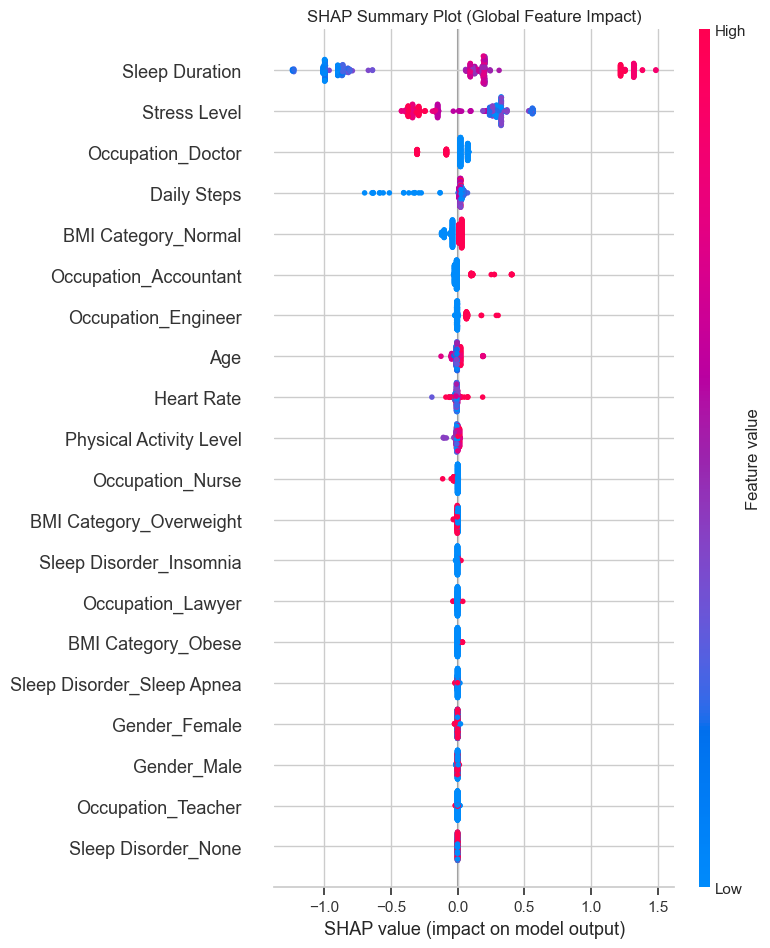

In [28]:
shap.summary_plot(shap_values, X_transformed, feature_names=all_features, show=False)
plt.title("SHAP Summary Plot (Global Feature Impact)")
plt.show()


1. **Sleep Duration and Stress Level are the dominant predictors**  
   The SHAP values show that *Sleep Duration* and *Stress Level* have the largest spread on the x-axis, meaning they contribute the most to the model’s prediction of sleep quality. Longer sleep duration (pink dots on the right) tends to increase predicted sleep quality, while higher stress levels (pink dots on the left) strongly decrease it.

2. **Daily physical/health metrics influence the model more than demographic categories**  
   Features such as *Daily Steps*, *Heart Rate*, and *Physical Activity Level* show noticeable but smaller SHAP impacts. In contrast, most demographic variables (occupation categories, gender, BMI categories) cluster tightly around zero, meaning the model learns very little predictive signal from them.

3. **Occupation and BMI categories have minimal direct impact**  
   The SHAP distributions for occupation one-hot features are almost centered at zero with very narrow ranges. This suggests the model does not rely on specific job roles or BMI labels to predict sleep quality, likely because these variables either have weak correlation with sleep outcomes or their effects are already captured by stronger behavioral metrics.

## 5. SHAP Bar Plot (Ranked Importance)

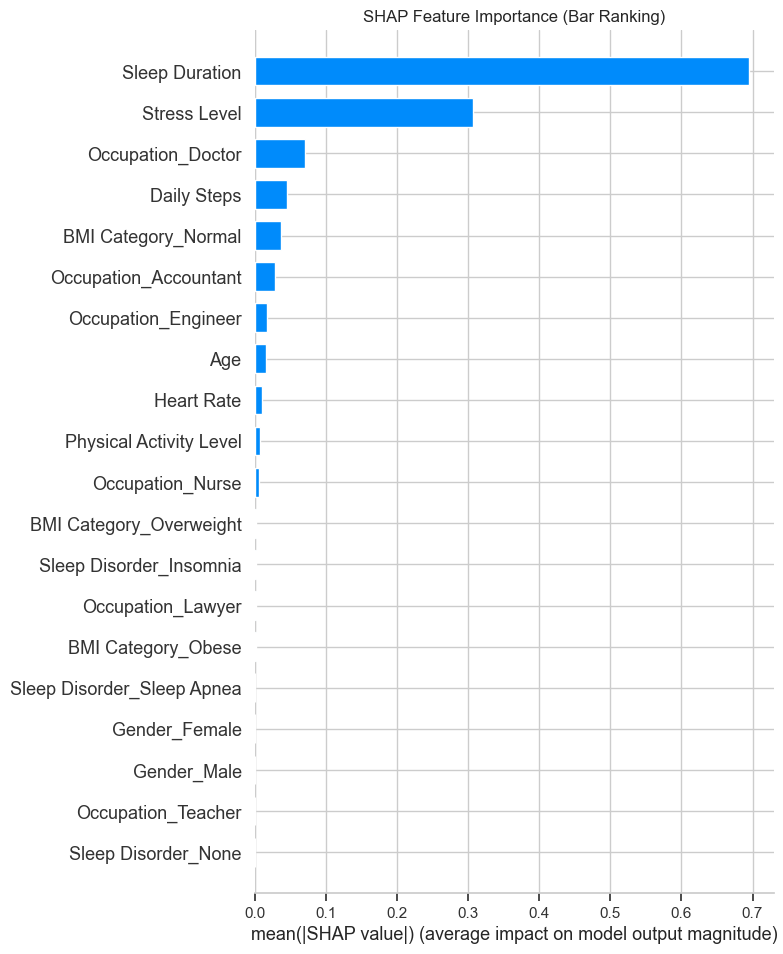

In [29]:

shap.summary_plot(
    shap_values, 
    X_transformed, 
    feature_names=all_features, 
    plot_type="bar", 
    show=False
)
plt.title("SHAP Feature Importance (Bar Ranking)")
plt.show()


1. **Sleep Duration overwhelmingly drives the model’s prediction**  
   The bar plot shows that *Sleep Duration* has by far the highest mean absolute SHAP value. This means the model consistently uses how long a person sleeps as the strongest signal when estimating sleep quality. In other words, variations in sleep duration create the largest shifts in predicted outcomes.

2. **Stress Level is the second major contributor**  
   *Stress Level* also has a substantial average impact, though noticeably lower than Sleep Duration. Higher stress levels are usually associated with lower predicted sleep quality, which matches typical physiological expectations.

3. **Most other features contribute very little**  
   Factors like occupation categories, BMI labels, age, and heart rate have very low SHAP magnitudes. This suggests the model finds only weak or inconsistent relationships between these variables and sleep quality. Their influence is so small that removing them would likely not change model performance much.


## 6. SHAP Dependence Plots

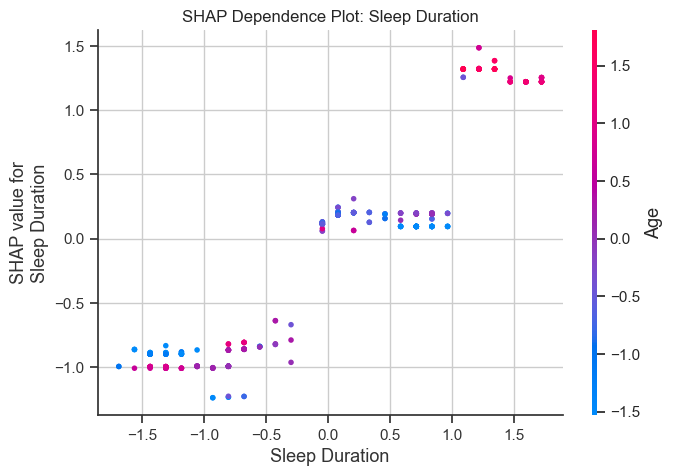

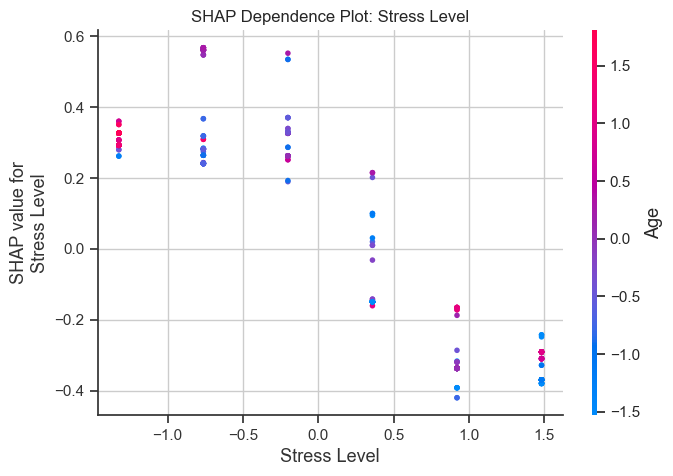

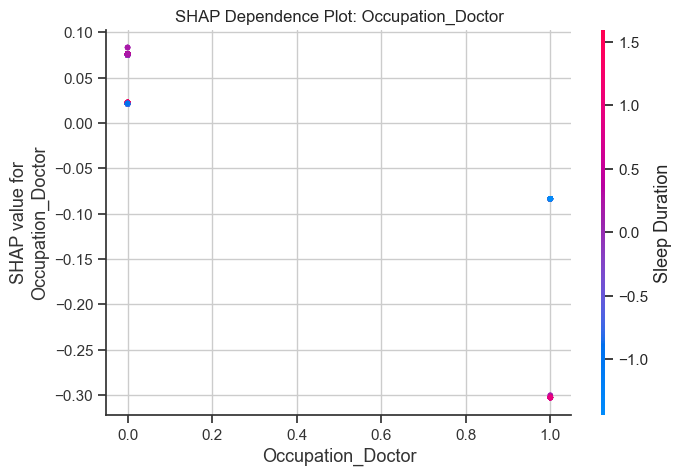

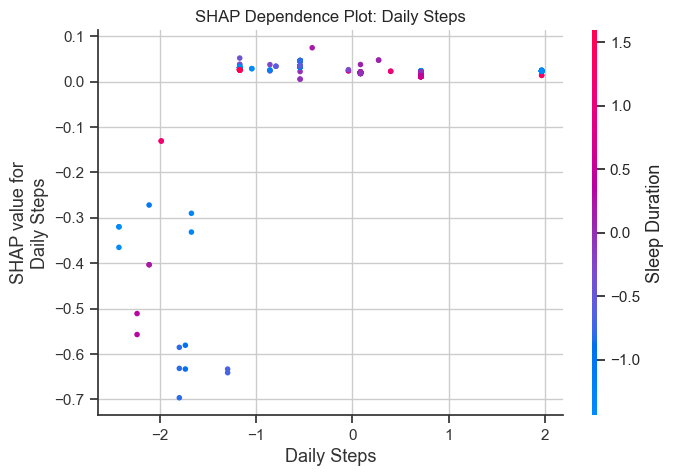

In [30]:
# SHAP mean absolute contributions
importance = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(importance)[::-1][:4]
top_features = [all_features[i] for i in top_idx]

top_features


for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_transformed, feature_names=all_features, show=False)
    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.show()


#### 1. Sleep Duration — clear positive relationship  
The SHAP dependence plot shows that as *Sleep Duration* increases, the SHAP values rise sharply. This means the model predicts significantly higher sleep quality for people who sleep longer. The points also cluster into levels (likely due to discrete or binned sleep durations), but the upward trend is consistent across all ages.

#### 2. Stress Level — higher stress consistently lowers prediction  
For *Stress Level*, the SHAP values drop as stress increases. Low stress (left side) produces positive SHAP contributions, while high stress shifts the SHAP values below zero. This indicates that stress acts as a strong negative predictor, reducing sleep quality in the model’s output.

#### 3. Occupation and Daily Steps show weak or noisy effects  
The dependence plots for *Occupation_Doc* and *Daily Steps* have very small SHAP magnitudes. Even when the feature value changes, the SHAP values stay close to zero. This means the model finds only weak relationships here. For Daily Steps, lower step counts slightly reduce predicted sleep quality, but the effect is minor compared to Sleep Duration or Stress Level.

## Feature Grouping

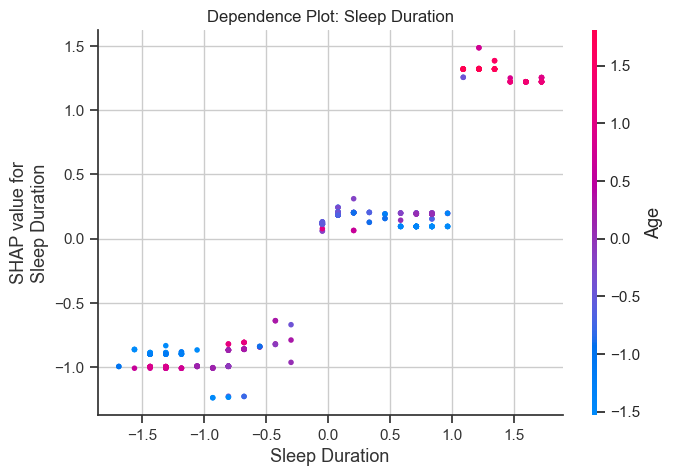

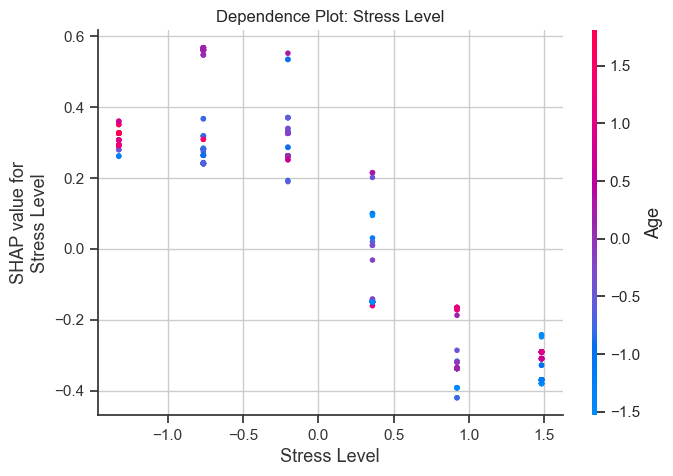

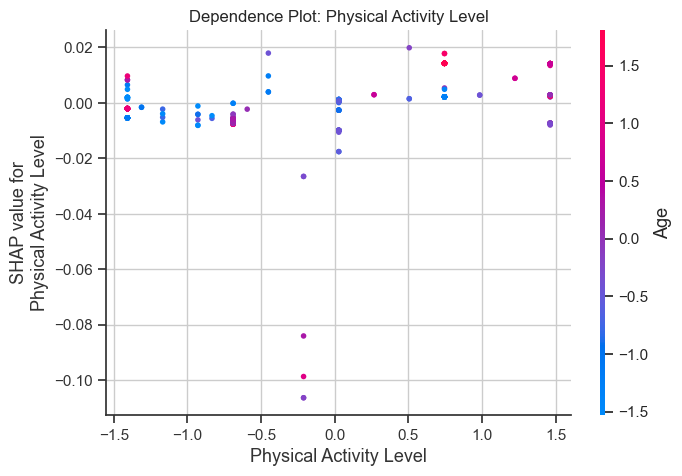

In [31]:
manual_feats = ["Sleep Duration", "Stress Level", "Physical Activity Level"]

for mf in manual_feats:
    # Find matching encoded feature name
    idx = [i for i, f in enumerate(all_features) if mf in f]
    if len(idx) == 0:
        continue
        
    shap.dependence_plot(
        all_features[idx[0]], 
        shap_values, 
        X_transformed, 
        feature_names=all_features,
        show=False
    )
    plt.title(f"Dependence Plot: {mf}")
    plt.show()

#### 1. Sleep Duration — strongest and most stable positive effect  
The dependence plot again shows a clear step-like increase in SHAP values as sleep duration increases. Longer sleep consistently pushes the model toward predicting higher sleep quality. The color gradient (age) is evenly mixed across the plot, meaning age does not interact strongly with sleep duration in the model.

#### 2. Stress Level — smooth negative trend  
Stress Level shows a clean downward pattern: low stress produces positive SHAP values, while high stress produces negative ones. This confirms that stress is the second most influential predictor, and its effect is monotonic—higher stress reliably leads to lower predicted sleep quality.

#### 3. Physical Activity Level — very small but slightly positive effect  
The SHAP values for Physical Activity Level are close to zero for most data points. However, there is a mild positive trend: higher activity levels are associated with slightly higher SHAP values, meaning more daily movement gives a small boost to predicted sleep quality. Still, the effect size is tiny compared with Sleep Duration or Stress Level.

## 9. SHAP Force Plot

In [32]:

sample_id = 5
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_id],
    feature_names=all_features
)


1. **Positive drivers dominate the prediction**  
   The plot shows that *Sleep Duration*, *Daily Steps*, and *Stress Level (low)* all push the prediction to the right (higher sleep quality). These features provide the main positive contributions, raising the model’s output above the baseline value.

2. **A few negative contributors pull the prediction down**  
   *BMI Category: Obese* and *Heart Rate* appear on the left side of the force plot, pushing the prediction downward. Although these effects are noticeable, they are smaller compared with the combined positive impact of sleep duration and activity-related features.

3. **Net effect: prediction ends up moderately above baseline**  
   After adding all positive and negative SHAP contributions, the model outputs around **5.96**, which is higher than the baseline prediction. This means that the sample’s good behaviors (longer sleep, more steps, lower stress) outweigh the negative health indicators.
